In [ ]:
import os
from pathlib import Path
import scipy
from matplotlib import pyplot as plt
import numpy as np
import math
from scipy.io import loadmat
import h5py
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


# GLM Tutorial: From Behavioral Events to an Encoding Model

This notebook builds a simple encoding model for widefield imaging data.

Learning goals:
- align behavioral trial times to imaging frames
- build interpretable regressors from task events
- expand event times into time-lagged design-matrix kernels
- fit a ridge-regression encoding model


## Link to download the data: https://fz-juelich.sciebo.de/s/indrrBDW83WycWK

In [ ]:
from pathlib import Path
import math
import warnings

import h5py
import numpy as np
from matplotlib import pyplot as plt
from scipy.io import loadmat

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------------
# Student-editable parameters
# ---------------------------
SESSION_ROOT = Path(
    r"E:\GLM_project\20250502_121114\20250502_121114" # Update this to your session directory path.
)
BHV_PATH = SESSION_ROOT / "2976_LickingLama_20250502_121114.mat"
VC_PATH = SESSION_ROOT / "Vc.mat"
VIDR_PATH = SESSION_ROOT / "vidR.mat"
SAVE_PATH = SESSION_ROOT / "encoding_results_13_march_2026"

TRIALS_TO_SKIP = 10
RANDOM_SEED = 7

# Set this to False if the video regressors are not available.
USE_VIDEO_REGRESSORS = True

# Kernel durations in seconds.
# Try changing these later to see how temporal context affects the model.
PRE_TRIG_DUR = 0.5
POST_TRIG_DUR = 8.0
PRE_STIM_DUR = 0.2
POST_STIM_DUR = 3.0
PRE_MOVE_DUR = 0.2
POST_MOVE_DUR = 3.0

np.random.seed(RANDOM_SEED)
SAVE_PATH.mkdir(parents=True, exist_ok=True)

data = loadmat(
    BHV_PATH,
    squeeze_me=True,
    struct_as_record=False,
)
bhv = data["SessionData"]

opts = dict(
    skipIfExist=False,
    showOrthplot=False,
    preTrigDur=PRE_TRIG_DUR,
    postTrigDur=POST_TRIG_DUR,
    nrFolds=20,
    testFrac=0.1,
    removeAutoTrials=True,
    innateTask=False,
    videoDims=100,
    preStimDur=PRE_STIM_DUR,
    postStimDur=POST_STIM_DUR,
    preMoveDur=PRE_MOVE_DUR,
    postMoveDur=POST_MOVE_DUR,
    cvRegs=["time", "choice", "prevChoice", "success", "prevSuccess", "water", "licks", "video"],
)

with h5py.File(VC_PATH, "r") as f:
    Vc = f["Vc"][:]
    trialOn = f["trialOn"][:]
    U = f["U"][:].T
    ledInfo = f["ledInfo"][:]
    frameInfo = f["frameInfo"][:]

print(f"Behavior fields: {bhv._fieldnames}")
print(f"Temporal components (Vc) shape: {Vc.shape}")
print(f"trialOn shape: {trialOn.shape}")
print(f"Spatial components (U) shape: {U.shape}")
print(f"frameInfo shape: {frameInfo.shape}")
print(f"Video regressors enabled: {USE_VIDEO_REGRESSORS}")
print(f"Video regressor path: {VIDR_PATH}")


In [ ]:
# include jpg photo
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("task.JPG")

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()


## 1. Align Trial Onsets to Imaging Frames

The behavioral file stores trial start times in seconds, while the imaging data are indexed by frame number.
Before we can build regressors, we need to convert every trial onset into the corresponding imaging frame.

What this step does:
- removes invalid trial entries
- reads the imaging timestamps from `frameInfo`
- finds the first imaging frame after each trial onset
- estimates the imaging sampling rate

Why it matters:
- every later regressor is defined in frame units
- incorrect alignment here will shift all kernels and degrade the model


In [ ]:
trialOn_clean = trialOn[:, ~np.isnan(trialOn[0, :])].T

print(f"Valid trials found: {trialOn_clean.shape[0]}")
print("Columns in trialOn_clean: [reference frame, trial start time (s), trial number]")

trialOn_clean[:5]


In [ ]:
nrTrials = trialOn_clean.shape[0]
trialOnFrames = np.zeros(nrTrials, dtype=np.int64)

if frameInfo.shape[0] == 2 and frameInfo.shape[1] > 2:
    frameInfo = frameInfo.T

t_frames = frameInfo[:, 1]

for i in range(nrTrials):
    t0 = trialOn_clean[i, 1]
    idx = np.flatnonzero(t_frames > t0)
    trialOnFrames[i] = (idx[0] + 1) if idx.size else 0  # keep MATLAB-style 1-based indexing

sRate = 1 / np.median(np.diff(frameInfo[:, 1]))

print(f"trialOnFrames shape: {trialOnFrames.shape}")
print(f"Estimated sampling rate: {sRate:.2f} Hz")


In [ ]:
opts["frameRate"] = sRate
opts["trialDur"] = opts["preTrigDur"] + opts["postTrigDur"]
opts["framesPerTrial"] = math.ceil(opts["trialDur"] * opts["frameRate"] + 1)

opts["preTrig"] = math.ceil(opts["frameRate"] * opts["preTrigDur"])
opts["postTrig"] = math.ceil(opts["frameRate"] * opts["postTrigDur"])

opts["stimPreTime"] = math.ceil(opts["preStimDur"] * opts["frameRate"])
opts["stimPostTime"] = math.ceil(opts["postStimDur"] * opts["frameRate"])

opts["movePreTime"] = math.ceil(opts["preMoveDur"] * opts["frameRate"])
opts["movePostTime"] = math.ceil(opts["postMoveDur"] * opts["frameRate"])

print(f"Frames per trial window: {opts['framesPerTrial']}")
print(f"Cognitive kernel: {-opts['preTrig']} to +{opts['postTrig']} frames")
print(f"Stimulus kernel: {-opts['stimPreTime']} to +{opts['stimPostTime']} frames")
print(f"Movement kernel: {-opts['movePreTime']} to +{opts['movePostTime']} frames")


In [ ]:
from utils import selectBehaviorTrials

rewarded = bhv.Rewarded
useIdx = np.ones(len(rewarded), dtype=bool)
useIdx[:TRIALS_TO_SKIP] = False

# Important: replace bhv with the filtered object so behavior arrays stay aligned with trialTimes.
bhv = selectBehaviorTrials(bhv, useIdx)

nrTrials = int(np.sum(useIdx))
trialTimes = trialOnFrames[useIdx]

print(f"Trials kept: {nrTrials}")
print(f"Trials skipped at the start: {TRIALS_TO_SKIP}")


In [ ]:
# Preallocate arrays for trial-by-trial event times in frame units.
water = np.full(nrTrials, np.nan, dtype=float)
stimTimes = np.full(nrTrials, np.nan, dtype=float)
punishTime = np.full(nrTrials, np.nan, dtype=float)

firstLickR = [np.nan] * nrTrials
nextLickR = [np.nan] * nrTrials

frameRate = opts["frameRate"]


## 2. Build Cognitive Regressors

These regressors describe trial-level task variables:
- `choiceGo`: trials in which the animal made a choice
- `choiceNOGO`: trials without a choice
- `success`: rewarded trials

We first extract event times from the behavioral structure, then convert those times into a binary event matrix.


In [ ]:
for iTrials in range(nrTrials):
    stimTimes[iTrials] = bhv.RawEvents.Trial[iTrials].States.PlayStimulus[0]
    stimTimes[iTrials] = np.floor(stimTimes[iTrials] * frameRate) + trialTimes[iTrials]

    if hasattr(bhv.RawEvents.Trial[iTrials].Events, "TouchShaker1_2"):
        cData = bhv.RawEvents.Trial[iTrials].Events.TouchShaker1_2
        cData = np.unique(np.floor(cData * frameRate) + trialTimes[iTrials])

        if cData.size != 0:
            firstLickR[iTrials] = cData[0]
            nextLickR[iTrials] = cData[1:]

    reward_temp = bhv.RawEvents.Trial[iTrials].States.Reward
    reward0 = reward_temp[0] if np.ndim(reward_temp) > 0 else reward_temp
    if not np.isnan(reward0):
        water[iTrials] = np.floor(reward0 * frameRate) + trialTimes[iTrials]

    punish_temp = bhv.RawEvents.Trial[iTrials].States.HardPunish
    punish0 = punish_temp[0] if np.ndim(punish_temp) > 0 else punish_temp
    if not np.isnan(punish0):
        punishTime[iTrials] = np.floor(punish0 * frameRate) + trialTimes[iTrials]

print(f"Trials with stimulus times: {np.sum(~np.isnan(stimTimes))}")
print(f"Trials with reward delivery: {np.sum(~np.isnan(water))}")
print(f"Trials with punishment: {np.sum(~np.isnan(punishTime))}")


In [ ]:
from utils import makeLogical

cogLabels = ["choiceGo", "choiceNOGO", "success"]
eventType = np.ones(len(cogLabels), dtype=int)
events = np.zeros((Vc.shape[0], len(cogLabels)), dtype=bool)

events[:, 0] = makeLogical(trialTimes[~bhv.DidNotChoose.astype(bool)], Vc.shape[0])
events[:, 1] = makeLogical(trialTimes[bhv.DidNotChoose.astype(bool)], Vc.shape[0])
events[:, 2] = makeLogical(trialTimes[bhv.Rewarded.astype(bool)], Vc.shape[0])

print("Event counts per cognitive regressor:")
for label, col in zip(cogLabels, events.T):
    print(f"  {label}: {int(col.sum())}")


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for i, label in enumerate(cogLabels):
    ax = axes[i]
    event_times = np.where(events[:, i])[0]
    ax.vlines(event_times, 0, 1, colors="C0", linewidth=2, alpha=0.7)
    ax.set_ylim(-0.5, 1.5)
    ax.set_ylabel(label, fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Frame", fontsize=12)
plt.tight_layout()
plt.show()

cog_counts = events.sum(axis=0)
plt.figure(figsize=(6, 4))
plt.bar(cogLabels, cog_counts, color="C0", alpha=0.8)
plt.ylabel("Number of events")
plt.title("How often does each cognitive event occur?")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### Time-Expanded Design Matrix for Cognitive Regressors

A single event time is not enough for the model, because neural activity can change before and after the event.
We therefore expand each event into a kernel of time lags.

For event type 1, the number of columns is:

$$
\text{kernel length} = \text{preTrig} + \text{postTrig} + 1
$$

Interpretation:
- each row is one imaging frame
- each column is one lag relative to the event
- each block of columns belongs to one regressor label

Try changing this later:
- reduce `POST_TRIG_DUR` to test whether long post-event kernels are necessary
- increase `PRE_TRIG_DUR` to look for anticipatory activity


In [ ]:
from reg import makeDesignMatrix_noTrials

cogR, cogIdx = makeDesignMatrix_noTrials(events, eventType, cogLabels, opts)

print(f"cogR shape: {cogR.shape}")
print(f"Columns per cognitive regressor block: {cogR.shape[1] // len(cogLabels)}")


In [ ]:
DESIGN_SLICE = slice(1250, 3000)
X = cogR[DESIGN_SLICE, :]

plt.figure(figsize=(12, 4))
plt.imshow(X.astype(int), aspect="auto", interpolation="nearest", vmin=0, vmax=1)
plt.xlabel("Kernel columns (lags)")
plt.ylabel("Time (frames)")
plt.title("Cognitive design matrix block")
plt.show()


## 3. Build Stimulus Regressors

Here we separate stimulus events by sound frequency and add water delivery as another event stream.
This lets the model distinguish sensory drive from later outcome-related activity.



In [ ]:
stimFreqs = np.unique(bhv.audioFreq)
stimLabels = [f"audioStim_{int(f)}kHz" for f in stimFreqs]
stimLabels = stimLabels + ['water']
eventType = np.full(len(stimLabels), 3, dtype=int)
events = np.zeros((Vc.shape[0], len(stimLabels)), dtype=bool)

for iFreqs in range(len(stimFreqs)):  
    cIdx = (bhv.audioFreq == stimFreqs[iFreqs])
    events[:, iFreqs] = makeLogical(stimTimes[cIdx], Vc.shape[0])

events[:, len(stimFreqs) + 0] = makeLogical(water, Vc.shape[0])

opts["mPreTime"] = opts["stimPreTime"]
opts["mPostTime"] = opts["stimPostTime"]

In [ ]:
stimR, stimIdx = makeDesignMatrix_noTrials(events, eventType, stimLabels, opts)

stimIdx = stimIdx + np.max(cogIdx)

In [ ]:
# Plot stimulus events
fig, axes = plt.subplots(len(stimLabels), 1, figsize=(14, 10), sharex=True)

for i, label in enumerate(stimLabels):
    ax = axes[i] if len(stimLabels) > 1 else axes
    event_times = np.where(events[:, i])[0]
    ax.vlines(event_times, 0, 1, colors="C1", linewidth=2, alpha=0.7)
    ax.set_ylim(-0.5, 1.5)
    ax.set_ylabel(label, fontsize=10, fontweight="bold")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Frame", fontsize=12) if len(stimLabels) > 1 else axes.set_xlabel("Frame", fontsize=12)
plt.tight_layout()
plt.show()

stim_counts = events.sum(axis=0)
plt.figure(figsize=(8, 4))
plt.bar(stimLabels, stim_counts, color="C1", alpha=0.8)
plt.ylabel("Number of events")
plt.title("Stimulus and reward event counts")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 4. Add a Dummy Control Regressor

The dummy regressor acts as a sanity check.
It keeps the same overall sparsity as a real regressor block, but its columns are shuffled in time.

If the dummy regressor explains substantial variance, that is a warning sign that the model or evaluation procedure may be too permissive and fitting to noise.


In [ ]:
dummyLabel = ['dummy']

dummyEvents = makeLogical(trialTimes, Vc.shape[0])

dummyR, dummyIdx = makeDesignMatrix_noTrials(
    dummyEvents[:, None],      # ensure column shape (nrTimes x 1)
    [3],                  # eventType = 3
    dummyLabel,
    opts
)

dummyIdx = dummyIdx + np.max(stimIdx)

for iCol in range(dummyR.shape[1]):
    perm = np.random.permutation(dummyR.shape[0])
    dummyR[:, iCol] = dummyR[perm, iCol]

In [ ]:
# Plot dummy events
fig, ax = plt.subplots(figsize=(14, 4))
event_times = np.where(dummyEvents)[0]
ax.vlines(event_times, 0, 1, colors='C3', linewidth=2, alpha=0.7)
ax.set_ylim(-0.5, 1.5)
ax.set_ylabel('dummy', fontsize=10, fontweight='bold')
ax.set_xlabel('Frame', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Build Movement Regressors

Movement-related variables often explain a large fraction of cortical activity.
We include:
- first lick after the trial event
- later licks within the trial


In [ ]:
from utils import cat2_cell

moveLabels = ['firstLicksR', 'nextLicksR']
eventType = np.full(len(moveLabels), 3, dtype=int)
events = np.zeros((Vc.shape[0], len(moveLabels)), dtype=bool)

events[:, 0] = makeLogical(cat2_cell(firstLickR), Vc.shape[0])
events[:, 1] = makeLogical(cat2_cell(nextLickR), Vc.shape[0])

opts["mPreTime"] = opts["movePreTime"]
opts["mPostTime"] = opts["movePostTime"]

moveR, moveIdx = makeDesignMatrix_noTrials(events, eventType, moveLabels, opts)
moveIdx = moveIdx + np.max(dummyIdx)

In [ ]:
# Plot movement events
fig, axes = plt.subplots(len(moveLabels), 1, figsize=(14, 6), sharex=True)

for i, label in enumerate(moveLabels):
    ax = axes[i] if len(moveLabels) > 1 else axes
    event_times = np.where(events[:, i])[0]
    ax.vlines(event_times, 0, 1, colors="C2", linewidth=2, alpha=0.7)
    ax.set_ylim(-0.5, 1.5)
    ax.set_ylabel(label, fontsize=10, fontweight="bold")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Frame", fontsize=12) if len(moveLabels) > 1 else axes.set_xlabel("Frame", fontsize=12)
plt.tight_layout()
plt.show()

move_counts = events.sum(axis=0)
plt.figure(figsize=(6, 4))
plt.bar(moveLabels, move_counts, color="C2", alpha=0.8)
plt.ylabel("Number of events")
plt.title("Movement event counts")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 6. Build Video Regressors

Video regressors are continuous predictors rather than event-triggered kernels.
They usually come from low-dimensional projections of behavioral video, for example:
- face or body motion components
- global motion energy
- camera-derived latent variables such as posture or whisking



In [ ]:
opts['videoDims'] = 200

vidLabels = ["video", "motionVideo"]
vidR = loadmat(VIDR_PATH)['vidR']
vidR = np.pad(vidR, ((0, 2), (0, 0)), mode='constant')  # Padding the matrix with 2 rows of zeros at the bottom
vidIdx = np.concatenate([np.ones((opts['videoDims'], 1), dtype=int),np.full((opts['videoDims'], 1), 2, dtype=int)], axis=0) + np.max(moveIdx)


In [ ]:
print("Regressor block shapes before concatenation:")
print("  cogR:", cogR.shape)
print("  stimR:", stimR.shape)
print("  dummyR:", dummyR.shape)
print("  moveR:", moveR.shape)
print("  vidR:", vidR.shape)
print("Total number of regressors:", cogR.shape[1] + stimR.shape[1] + dummyR.shape[1] + moveR.shape[1] + vidR.shape[1])

## 7. Create the Full Design Matrix

This is where all regressor families are concatenated into one matrix.
Each family keeps its own group index so we can later:
- inspect boundaries in the matrix
- remove redundant columns
- quantify how much each regressor family contributes to performance


In [ ]:
fullR = np.concatenate((cogR, stimR, dummyR, moveR, vidR), axis=1)
regIdx = np.concatenate((cogIdx, stimIdx, dummyIdx, moveIdx, vidIdx), axis=0)
regLabels = cogLabels + stimLabels + dummyLabel + moveLabels + vidLabels

print(f"Full design matrix shape before cleanup: {fullR.shape}")
print(f"Number of regressor groups: {len(regLabels)}")
print("Regressor groups:", regLabels)


In [ ]:
# Visualize design matrix with regressor group boundaries
regIdx_flat = regIdx.flatten()
# Pick a manageable window so it's readable
t0, t1 = 1250, 3000          # time window (frames)
x0, x1 = 0, fullR.shape[1] # regressor window (columns)

X = fullR[t0:t1, x0:x1]

plt.figure(figsize=(14, 8))
plt.imshow(X.astype(int), aspect="auto", interpolation="nearest", vmin=0, vmax=1)

# Find boundaries where regressor group changes
boundaries = np.where(np.diff(regIdx_flat))[0] + 1
for b in boundaries:
    plt.axvline(b, color="red", linewidth=1.5, alpha=0.7)

# Add labels for each regressor group
starts = np.concatenate(([0], boundaries))
ends = np.concatenate((boundaries, [len(regIdx_flat)]))
centers = (starts + ends) / 2

for i, center in enumerate(centers):
    if i < len(regLabels):
        label = regLabels[int(regIdx_flat[int(starts[i])]) - 1]
        plt.text(center, -50, label, ha="center", va="bottom", rotation=90, fontsize=9, fontweight="bold")

plt.xlabel("Regressor columns", fontsize=12)
plt.ylabel("Time (frames)", fontsize=12)
plt.tight_layout()
plt.show()

## 8. Remove Sparse or Redundant Columns

Two common issues can appear after concatenating many regressor blocks:
- some columns are nearly empty because there are too few events at that lag
- some columns are linearly redundant with others

The next cell removes both cases before model fitting.

### Rank deficiency vs multicollinearity

These ideas are related, but they are not identical.

- **Rank deficiency** means one or more columns can be written exactly as a combination of other columns.
- In that case, the design matrix does not have full rank, and the regression coefficients are not uniquely defined.
- **Multicollinearity** means columns are not exactly identical, but they are still highly correlated.
- In that case, the model can still be fit, but coefficient estimates become unstable and harder to interpret.

Why our design matrix is vulnerable to both:
- nearby time-lag columns from the same regressor are naturally similar
- stimulus, reward, movement, and video variables can overlap strongly in time
- long kernels increase overlap between regressor blocks

Practical consequence:
- QR decomposition helps detect exact redundancy
- ridge regression helps handle strong correlation even when the matrix is not exactly rank-deficient


In [ ]:
rejIdx = np.nansum(np.abs(fullR), axis=0) < 10
Rkeep = fullR[:, ~rejIdx]

col_norm = np.sqrt(np.sum(Rkeep**2, axis=0))
col_norm[col_norm == 0] = 1.0

X = Rkeep / col_norm
_, fullQRR = np.linalg.qr(X, mode="reduced")

showOrthplot = False
diagR = np.abs(np.diag(fullQRR))
r1 = np.asarray(fullQRR).ravel(order="F")[0]
threshold = max(fullR.shape) * np.spacing(abs(r1))
rank_mask = diagR > threshold

if np.sum(rank_mask) < fullQRR.shape[1]:
    redundant_cols = ~rank_mask
    print(
        f"Design matrix is rank-deficient. Removing {np.sum(redundant_cols)}/{np.sum(~rejIdx)} additional regressors."
    )
    good_idx = np.where(~rejIdx)[0]
    rejIdx[good_idx] = redundant_cols
    showOrthplot = True

if opts["showOrthplot"] or showOrthplot:
    plt.figure(figsize=(6, 3))
    plt.plot(np.abs(np.diag(fullQRR)))
    plt.axhline(threshold, color="red", linestyle="--", linewidth=1, label="rank threshold")
    plt.ylim([0, 1.1])
    plt.title("QR diagonal values used for rank check")
    plt.xlabel("Column index")
    plt.ylabel("|diag(R)|")
    plt.legend()
    plt.tight_layout()
    plt.show()

fullR = fullR[:, ~rejIdx]
regIdx_kept = regIdx[~rejIdx]

print(f"Rejected {np.sum(rejIdx)}/{len(rejIdx)} sparse or redundant columns")
print(f"Final design matrix shape: {fullR.shape}")


In [ ]:
diag_vals = np.abs(np.diag(fullQRR))
threshold = max(fullR.shape) * np.spacing(abs(fullQRR.flat[0]))
zero_cols = np.where(diag_vals <= threshold)[0]
zero_regs = regIdx[zero_cols]
unique_regs = np.unique(zero_regs)

if unique_regs.size == 0:
    print("No fully redundant regressor groups were detected.")
else:
    print("Regressor groups contributing redundant columns:")
    for r in unique_regs:
        print(f"  {int(r)}: {regLabels[int(r) - 1]}")



In [ ]:
print("cogR:", cogR.shape)
print("stimR:", stimR.shape)
print("dummyR:", dummyR.shape)
print("moveR:", moveR.shape)
print("vidR:", vidR.shape)
print("fullR:", fullR.shape)


In [ ]:
regIdx_flat = regIdx_kept.flatten()
X = fullR

plt.figure(figsize=(10, 8))
plt.imshow(X.astype(int), aspect="auto", interpolation="nearest", vmin=0, vmax=1)

boundaries = np.where(np.diff(regIdx_flat))[0] + 1
for b in boundaries:
    plt.axvline(b, color="red", linewidth=1)

starts = np.concatenate(([0], boundaries))
ends = np.concatenate((boundaries, [len(regIdx_flat)]))
centers = (starts + ends) / 2

for i, center in enumerate(centers):
    label = regLabels[int(regIdx_flat[int(starts[i])]) - 1]
    plt.text(center, -50, label, ha="center", va="bottom", rotation=90, fontsize=10)

plt.xlabel("Regressors (columns)")
plt.ylabel("Time (frames)")
plt.ylim(3500,0)
plt.tight_layout()
plt.show()


## 9. Fit the Encoding Model

We now predict the low-dimensional imaging activity `Vc` from the cleaned design matrix using ridge regression.

Why ridge regression?
- neighboring lags are correlated
- different regressor families overlap in time
- regularization stabilizes the fit and makes the comparison across regressor sets more meaningful


In [ ]:
taskR = np.concatenate((cogR, stimR), axis=1)
task_rows = np.sum(taskR == 1, axis=1)
startIdx0 = int(np.argmax(task_rows > 0)) if np.any(task_rows > 0) else 0
startIdx0 = startIdx0 + 1

print(f"First frame containing task-related regressors: {startIdx0}")


In [ ]:
Vc[:startIdx0, :] = 0
fullR[:startIdx0, :] = 0


In [31]:
from reg import SVDStack, mint_calc_score, ridge_MML
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_predict

newVc = Vc - np.mean(Vc, axis=0, keepdims=True)
svd_stack = SVDStack(u=U, svt=newVc)
calc_score = mint_calc_score(svd_stack)

design_mean = fullR.mean(axis=0, keepdims=True)
design_std = fullR.std(axis=0, keepdims=True)
design_std[design_std == 0] = 1.0
design_norm = (fullR - design_mean) / design_std

alphas = ridge_MML(svd_stack.svt, design_norm, regress=False)

mdl = Ridge(alpha=alphas, fit_intercept=False)
preds = cross_val_predict(mdl, design_norm, svd_stack.svt, cv=10, n_jobs=-1)
scores = calc_score(svd_stack.svt, preds)

print(f"R2: {scores:.4f}")
print(f"Alpha range: {np.min(alphas):.4f} to {np.max(alphas):.4f}")


R2: 0.0124
Alpha range: 1813.0264 to 10547.9979


### Compare Predicted and Observed Components

The next plot shows:
- one SVD component with the highest variance
- a short time window for readability
- the observed trace and the model prediction


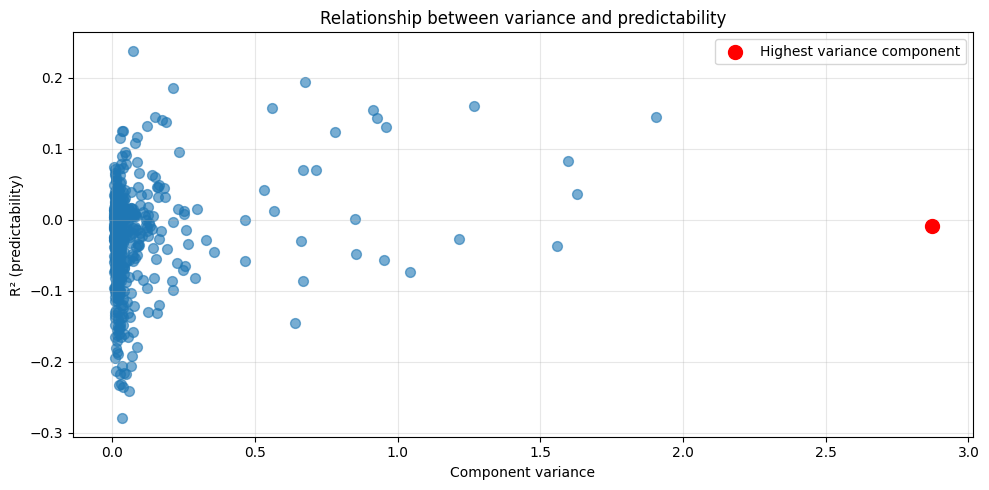

Correlation between variance and R²: 0.207


In [32]:
## Check: Is high variance correlated with predictability?

# Compute variance and R2 score for each component
component_r2 = []
for i in range(svd_stack.svt.shape[1]):
    residuals = svd_stack.svt[:, i] - preds[:, i]
    ss_res = np.sum(residuals ** 2)
    ss_tot = np.sum((svd_stack.svt[:, i] - np.mean(svd_stack.svt[:, i])) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    component_r2.append(r2)

component_r2 = np.array(component_r2)

component_var = np.var(svd_stack.svt, axis=0) # variance of each component across time
best_component = int(np.argmax(component_var))

# Plot variance vs R2 score
plt.figure(figsize=(10, 5))
plt.scatter(component_var, component_r2, alpha=0.6, s=50)
plt.xlabel("Component variance")
plt.ylabel("R² (predictability)")
plt.title("Relationship between variance and predictability")
plt.grid(True, alpha=0.3)

# Highlight the highest variance component
plt.scatter([component_var[best_component]], [component_r2[best_component]], 
            color="red", s=100, label="Highest variance component", zorder=5)
plt.legend()
plt.tight_layout()
plt.show()

correlation = np.corrcoef(component_var, component_r2)[0, 1]
print(f"Correlation between variance and R²: {correlation:.3f}")

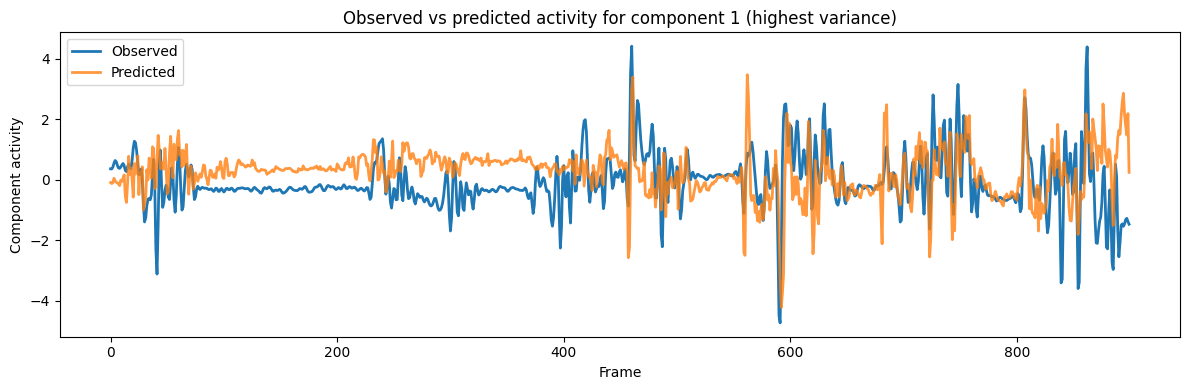

In [33]:

trace_window = slice(startIdx0, min(startIdx0 + 900, svd_stack.svt.shape[0]))

plt.figure(figsize=(12, 4))
plt.plot(svd_stack.svt[trace_window, best_component], label="Observed", linewidth=2)
plt.plot(preds[trace_window, best_component], label="Predicted", linewidth=2, alpha=0.8)
plt.xlabel("Frame")
plt.ylabel("Component activity")
plt.title(f"Observed vs predicted activity for component {best_component} (highest variance)")
plt.legend()
plt.tight_layout()
plt.show()




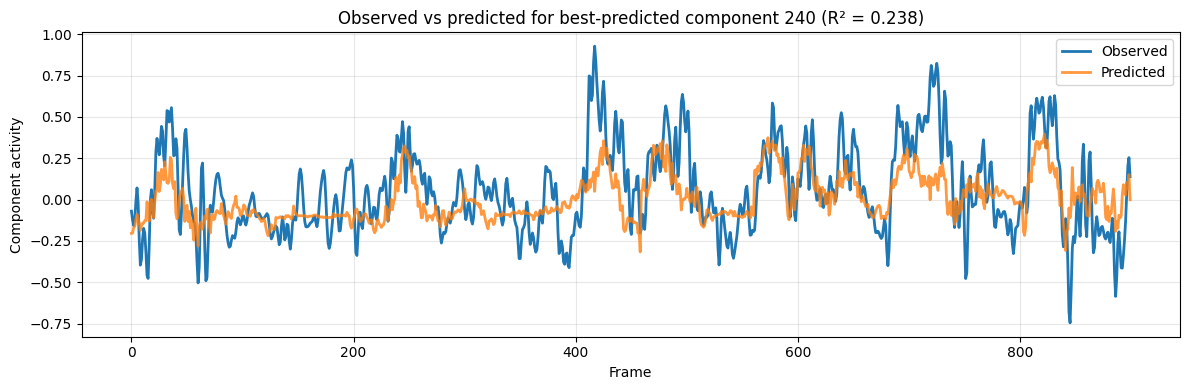

Best R² component: 240
Best R² score: 0.2378
Variance of this component: 0.0735


In [34]:
## Plot the component with highest R² score

best_r2_component = int(np.argmax(component_r2))
trace_window = slice(startIdx0, min(startIdx0 + 900, svd_stack.svt.shape[0]))

plt.figure(figsize=(12, 4))
plt.plot(svd_stack.svt[trace_window, best_r2_component], label="Observed", linewidth=2)
plt.plot(preds[trace_window, best_r2_component], label="Predicted", linewidth=2, alpha=0.8)
plt.xlabel("Frame")
plt.ylabel("Component activity")
plt.title(f"Observed vs predicted for best-predicted component {best_r2_component} (R² = {component_r2[best_r2_component]:.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best R² component: {best_r2_component}")
print(f"Best R² score: {component_r2[best_r2_component]:.4f}")
print(f"Variance of this component: {component_var[best_r2_component]:.4f}")

In [35]:
maps = {}
opts["frames_per_trial"] = 75
opts["xtol"] = 100
opts["map_met"] = "r2"   
opts["sample_trials"] = -1

frames = opts["frames_per_trial"]
nrTrials = int(np.floor(len(svd_stack) / frames))

randIdx = np.arange(nrTrials * frames).reshape(frames, -1)
trialIdx = np.random.permutation(randIdx.shape[1])
randIdx = randIdx[:, trialIdx]
frame_idx = randIdx.reshape(-1)

print(f"Frames per trial used for maps: {frames}")
print(f"Number of trials contributing to maps: {nrTrials}")


Frames per trial used for maps: 75
Number of trials contributing to maps: 620


In [36]:
from reg import vis_score

opts["sample_trials"] = nrTrials
maps = vis_score(svd_stack, preds, opts, frame_idx)

print(f"Map shape: {maps.shape}")
print(f"Mean map value: {np.nanmean(maps):.4f}")


Map shape: (540, 640)
Mean map value: 0.0866


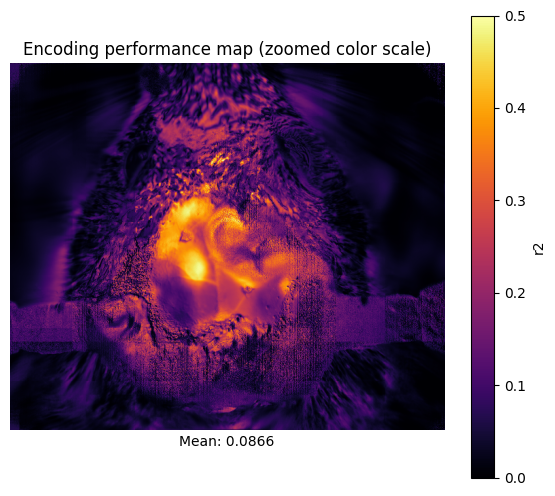

In [37]:
score_fig2, score_ax2 = plt.subplots(figsize=(7, 6))

score_ax2.grid(False)
score_ax2.spines[["bottom", "left", "right", "top"]].set_visible(False)
score_ax2.set_xticks([])
score_ax2.set_yticks([])

im2 = score_ax2.imshow(maps, cmap="inferno", vmin=0, vmax=0.5)
score_ax2.set_title("Encoding performance map (zoomed color scale)")
score_ax2.set_xlabel(f"Mean: {np.nanmean(maps):.4f}")

cbar2 = score_fig2.colorbar(im2, ax=score_ax2)
cbar2.set_label(opts["map_met"])


## 10. Compare Regressor Sets

#### In this section we ask an important question: which types of regressors help the model most?
#### We will compare models in two ways.

1️⃣ Progressive models
Start with a small model and add regressor groups step by step.
This tells us:

- does performance improve when we add more information?
- which groups add the most predictive power?

2️⃣ Leave-one-group-out models
Start with the full model and remove one group at a time.
This tells us:

- which groups are important
- which groups might be redundant

### Step 1. Identify regressor groups

Each regressor belongs to a group (task, movement, video, etc.).
First we collect the columns belonging to each group.

In [38]:
from collections import OrderedDict

group_columns = OrderedDict()

for group_id, label in enumerate(regLabels, start=1):
    cols = np.where(regIdx_kept.flatten() == group_id)[0]
    if cols.size > 0:
        group_columns[label] = cols

group_columns.keys()

odict_keys(['choiceGo', 'choiceNOGO', 'audioStim_6kHz', 'audioStim_11kHz', 'audioStim_14kHz', 'water', 'dummy', 'firstLicksR', 'nextLicksR', 'video', 'motionVideo'])

### Task: Print the number of regressors in each group.

In [39]:
# YOUR CODE HERE

### Step 2. Define a helper function

This function:

- normalizes the regressors

- fits a ridge regression model

- uses cross-validation

- computes the weighted model score

In [40]:
def evaluate_design_matrix(X_raw, y, u, cv=10):
    
    X_mean = X_raw.mean(axis=0, keepdims=True)
    X_std = X_raw.std(axis=0, keepdims=True)
    X_std[X_std == 0] = 1.0
    
    X_norm = (X_raw - X_mean) / X_std

    alphas_local = ridge_MML(y, X_norm, regress=False)

    mdl_local = Ridge(alpha=alphas_local, fit_intercept=False)

    preds_local = cross_val_predict(
        mdl_local,
        X_norm,
        y,
        cv=cv,
        n_jobs=-1,
    )

    local_stack = SVDStack(u=u, svt=y)
    local_score = mint_calc_score(local_stack)(y, preds_local)

    return float(local_score), preds_local

### TASK: Evaluate the full model.

In [ ]:
# YOUR CODE HERE

### Step 3. Define progressive models

Now we define models that gradually add regressor groups.

In [ ]:
progressive_sets = [
    ("task only", ["choiceGo", "choiceNOGO", "success"] + [lab for lab in stimLabels]),
    ("task + dummy", ["choiceGo", "choiceNOGO", "success"] + [lab for lab in stimLabels] + ["dummy"]),
    ("task + movement", ["choiceGo", "choiceNOGO", "success"] + [lab for lab in stimLabels] + moveLabels),
    ("task + movement + video", ["choiceGo", "choiceNOGO", "success"] + [lab for lab in stimLabels] + moveLabels + vidLabels),
    ("full model", list(group_columns.keys())),
]

### Task: Create your own progressive model list.

Example idea:

model 1: task only

model 2: task + dummy

model 3: task + movement

In [ ]:
# YOUR CODE HERE


### Step 4. Evaluate progressive models

Now we run each model and compute the score.

In [ ]:
comparison_results = []

for model_name, labels_to_use in progressive_sets:

    cols = np.concatenate(
        [group_columns[label] for label in labels_to_use if label in group_columns]
    )

    cols = np.unique(cols)

    if cols.size == 0:
        continue

    score_subset, _ = evaluate_design_matrix(
        fullR[:, cols],
        svd_stack.svt,
        U,
        cv=10
    )

    comparison_results.append(
        {
            "model": model_name,
            "type": "progressive",
            "score": score_subset,
        }
    )

comparison_results

### Step 5. Plot progressive model performance

In [ ]:
progressive_results = [
    r for r in comparison_results if r["type"] == "progressive"
]

plt.figure(figsize=(9,4))

plt.bar(
    [r["model"] for r in progressive_results],
    [r["score"] for r in progressive_results],
)

plt.ylabel("Weighted model score")
plt.title("Performance as we add regressor families")

plt.xticks(rotation=25)

plt.show()

### Task: Look at the plot and answer:

Which addition improves the model most?

Does performance plateau after some point?

Write your answer below.

### Step 6. Leave-one-group-out analysis

In [ ]:
# Compute the score of the full model directly

full_score, _ = evaluate_design_matrix(
    fullR,
    svd_stack.svt,
    U,
    cv=10
)

print("Full model score:", full_score)

In [ ]:
leave_one_out_results = []

for label, cols_to_drop in group_columns.items():
    
    # Keep all columns except the current group
    keep_cols = np.setdiff1d(np.arange(fullR.shape[1]), cols_to_drop)
    
    # Evaluate model without this group
    score_subset, _ = evaluate_design_matrix(
        fullR[:, keep_cols],
        svd_stack.svt,
        U,
        cv=10
    )
    
    # Store result
    leave_one_out_results.append({
        "model": f"without {label}",
        "type": "leave-one-out",
        "score": score_subset,
        "delta_vs_full": score_subset - full_score,
    })

leave_one_out_results

In [ ]:
delta_vs_full = score_subset - full_score
delta_vs_full

interpretation:

if it is negative, performance got worse after removing that group

if it is strongly negative, that group was important

if it is close to 0, removing that group did not matter much

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    [r["model"] for r in leave_one_out_results],
    [r["delta_vs_full"] for r in leave_one_out_results],
)

plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Score change relative to full model")
plt.title("Performance drop when removing one regressor group")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

interpretation:

Negative bar → removing this regressor makes the model worse → important regressor

Near zero → removing it does not change performance → less important

Positive bar → removing it improves the model → possibly noisy or redundant